# 03 Transfer Learning Classification

This notebook builds a transfer learning model for the Oxford-IIIT Pet Dataset.

In Notebook 02, we trained a custom CNN from scratch as a baseline model. That baseline achieved approximately 11.17% test accuracy. Although this was above random guessing for a 37-class problem, the model struggled to generalize strongly to unseen images.

In this notebook, we use a pretrained CNN as a feature extractor. The pretrained model has already learned useful visual features from a much larger image dataset. We then train a new classification head for the 37 pet breed classes.

This notebook will:

1. Load the Oxford-IIIT Pet Dataset.
2. Create training, validation, and test datasets.
3. Apply preprocessing appropriate for MobileNetV2.
    4. Load MobileNetV2 pretrained on ImageNet.
5. Train a new classification head.
6. Evaluate the transfer learning model.
7. Compare the transfer learning model against the baseline CNN.
8. Save the model, metrics, and figures.

## 1. Imports and Configuration

This section imports the libraries needed for TensorFlow/Keras transfer learning, dataset preparation, evaluation, and plotting.

The main pretrained architecture used in this notebook is MobileNetV2. MobileNetV2 is a lightweight CNN architecture designed for efficient inference, making it a good fit for both classification and possible deployment.

In [12]:
#
# Imports and Configuration
#

# Standard library imports
# random supports reproducible sampling.
# pathlib helps us manage project folders cleanly.

import os
import random
from pathlib import Path

# Core data science imports
# numpy supports numerical operations.
# pandas supports tabular summaries.
# matplotlib supports training and evaluation plots.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow imports
# TensorFlow and Keras are used to build and train the transfer learning model.
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers

# MobileNetV2 imports
# MobileNetV2 is the pretrained CNN architecture used in this notebook.
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Evaluation imports
# sklearn tools are used for classification reports and confusion matrices.
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility settings
# These seeds make random operations more repeatable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Project constants
# IMAGE_SIZE is set to 224 x 224 because MobileNetV2 commonly uses this input size.
IMAGE_SIZE = (224, 224)

# BATCH_SIZE controls how many images are processed at once.
BATCH_SIZE = 32

# Oxford-IIIT Pets contains 37 breed classes.
NUM_CLASSES = 37

# We create a validation split from the official training split.
VALIDATION_FRACTION = 0.20

# Initial transfer learning training settings.
# We first train only the classification head while the MobileNetV2 base is frozen.
EPOCHS_HEAD = 10
LEARNING_RATE_HEAD = 0.001

# Optional fine-tuning settings.
# We may use these later after the classification head has trained.
EPOCHS_FINE_TUNE = 10
LEARNING_RATE_FINE_TUNE = 1e-5

# Print version information for reproducibility.
print("TensorFlow version:", tf.__version__)
print("TensorFlow Datasets version:", tfds.__version__)

TensorFlow version: 2.19.1
TensorFlow Datasets version: 4.9.9


In [13]:
# SET UP SSL

import certifi
print(certifi.where())

os.environ["SSL_CERT_FILE"] = certifi.where()
print("SSL_CERT_FILE =", os.environ["SSL_CERT_FILE"])

/Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/venv/lib/python3.11/site-packages/certifi/cacert.pem
SSL_CERT_FILE = /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/venv/lib/python3.11/site-packages/certifi/cacert.pem


## 2. Project Directory Setup

This notebook saves its outputs into the same project folder structure used by the earlier notebooks.

This notebook will save:

- MobileNetV2 transfer learning model,
- training history,
- training curves,
- classification report,
- confusion matrix,
- metrics summary,
- model comparison table.

In [2]:
#
# Project Directory Setup
#

# Determine the project root.
# This assumes the notebook is either inside the notebooks folder
# or is being run from the project root.
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

# Define project output directories.
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
RESULTS_DIR = OUTPUT_DIR / "results"
MODEL_DIR = OUTPUT_DIR / "models"

# Create the directories if they do not already exist.
for directory in [DATA_DIR, OUTPUT_DIR, FIGURE_DIR, RESULTS_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)
print("Results directory:", RESULTS_DIR)
print("Model directory:", MODEL_DIR)

Project root: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project
Figure directory: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/figures
Results directory: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results
Model directory: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/models


## 3. Load the Oxford-IIIT Pet Dataset

We load the same Oxford-IIIT Pet Dataset used in Notebooks 01 and 02.

The prediction target remains the 37-class breed label.

In [3]:
#
# Load the Oxford-IIIT Pet Dataset
#

# Load the official train and test splits.
# as_supervised=False keeps the full example dictionary.
(ds_train_raw, ds_test_raw), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    as_supervised=False,
    with_info=True,
    shuffle_files=False
)

# Store split sizes.
num_train_raw = ds_info.splits["train"].num_examples
num_test = ds_info.splits["test"].num_examples
num_total = num_train_raw + num_test

# Extract human-readable breed names.
breed_names = ds_info.features["label"].names

print("Dataset name:", ds_info.name)
print("Dataset version:", ds_info.version)
print("Raw training examples:", num_train_raw)
print("Test examples:", num_test)
print("Total examples:", num_total)
print("Number of breed classes:", len(breed_names))

Dataset name: oxford_iiit_pet
Dataset version: 4.0.0
Raw training examples: 3680
Test examples: 3669
Total examples: 7349
Number of breed classes: 37


## 4. Create Training and Validation Splits

The official training split is divided into a training set and validation set. The validation set is used to monitor performance during model development.

The official test split is kept separate and used only for final evaluation.

In [4]:
#
# Create Training and Validation Splits
#

# Calculate validation size.
num_validation = int(num_train_raw * VALIDATION_FRACTION)
num_train = num_train_raw - num_validation

# Shuffle the official training split before separating it into train and validation sets.
ds_train_shuffled = ds_train_raw.shuffle(
    buffer_size=num_train_raw,
    seed=SEED,
    reshuffle_each_iteration=False
)

# Create validation and final training splits.
ds_val_raw = ds_train_shuffled.take(num_validation)
ds_train_raw_final = ds_train_shuffled.skip(num_validation)

print("Training examples:", num_train)
print("Validation examples:", num_validation)
print("Test examples:", num_test)

Training examples: 2944
Validation examples: 736
Test examples: 3669


## 5. Preprocessing for MobileNetV2

MobileNetV2 expects input images to be preprocessed in a specific way.

Unlike the baseline CNN notebook, where we manually scaled pixels to `[0, 1]`, this notebook uses MobileNetV2's official `preprocess_input` function. This function scales image values into the range expected by the pretrained ImageNet weights.

Each example is:

1. resized to `224 x 224`,
2. converted to floating point values,
3. preprocessed using MobileNetV2's official preprocessing function,
4. paired with the integer breed label.

In [5]:
#
# Preprocessing Function for MobileNetV2
#

def preprocess_example_mobilenet(example):
    """
    Convert a raw Oxford-IIIT Pet example into an image-label pair
    suitable for MobileNetV2 transfer learning.

    Parameters
    ----------
    example : dict
        One example from the TensorFlow Dataset.

    Returns
    -------
    image : tf.Tensor
        Resized and MobileNetV2-preprocessed image tensor.

    label : tf.Tensor
        Integer breed label.
    """

    # Extract image and breed label from the example dictionary.
    image = example["image"]
    label = example["label"]

    # Resize all images to the input size expected by the model.
    image = tf.image.resize(image, IMAGE_SIZE)

    # Convert to float32 before applying MobileNetV2 preprocessing.
    image = tf.cast(image, tf.float32)

    # Apply MobileNetV2's official preprocessing.
    # This scales pixels to the range expected by the pretrained model.
    image = preprocess_input(image)

    return image, label

## 6. Data Augmentation

We use modest data augmentation during training to improve generalization.

The augmentation layers are placed inside the model. Keras automatically applies them during training but not during validation or test inference.

In [6]:
#
# Data Augmentation Layers
#

# These augmentation layers are intentionally modest.
# Strong augmentation could distort breed-specific visual features.
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.10),
    ],
    name="data_augmentation"
)

## 7. Build TensorFlow Data Pipelines

This section converts the raw dataset splits into efficient batched datasets.

The pipeline:

1. applies MobileNetV2 preprocessing,
2. batches examples,
3. prefetches batches for performance.

In [7]:
#
# Build TensorFlow Data Pipelines
#

# AUTOTUNE allows TensorFlow to tune data-loading performance automatically.
AUTOTUNE = tf.data.AUTOTUNE

# Build the training dataset.
train_ds = (
    ds_train_raw_final
    .map(preprocess_example_mobilenet, num_parallel_calls=AUTOTUNE)
    .shuffle(buffer_size=num_train, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Build the validation dataset.
val_ds = (
    ds_val_raw
    .map(preprocess_example_mobilenet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Build the test dataset.
test_ds = (
    ds_test_raw
    .map(preprocess_example_mobilenet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Training batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Test batches:", len(test_ds))

Training batches: 92
Validation batches: 23
Test batches: 115


## 8. Inspect One Batch

Before building the model, we inspect one batch to confirm that the MobileNetV2 preprocessing pipeline is working correctly.

The expected image batch shape is:

`(batch_size, 224, 224, 3)`

Because MobileNetV2 preprocessing is applied, the pixel range should generally be around `[-1, 1]`.

In [8]:
#
# Inspect One Batch
#

# Take one batch from the training dataset.
for image_batch, label_batch in train_ds.take(1):

    # Print image and label shapes.
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)

    # Print minimum and maximum pixel values after MobileNetV2 preprocessing.
    print("Image pixel min:", tf.reduce_min(image_batch).numpy())
    print("Image pixel max:", tf.reduce_max(image_batch).numpy())

    # Print the first few labels.
    print("First 10 labels:", label_batch[:10].numpy())

2026-05-03 17:14:40.410369: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image pixel min: -1.0
Image pixel max: 1.0
First 10 labels: [ 3 13 15 36  1 32  6 13 25  0]


2026-05-03 17:14:41.255369: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
#
# Check Active Python Kernel
#

import sys

print("Python version:", sys.version)
print("Python executable:", sys.executable)

Python version: 3.11.3 (v3.11.3:f3909b8bc8, Apr  4 2023, 20:12:10) [Clang 13.0.0 (clang-1300.0.29.30)]
Python executable: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/venv/bin/python


## 9. Build the MobileNetV2 Transfer Learning Model

This section builds the transfer learning model.

The model has three major parts:

1. **Data augmentation layers** that apply modest random transformations during training.
2. **MobileNetV2 base model** pretrained on ImageNet.
3. **Custom classification head** for the 37 Oxford-IIIT Pet breed classes.

For the first training stage, the MobileNetV2 base is frozen. This means the pretrained convolutional layers keep their existing ImageNet weights while only the new classification head is trained.

In [14]:
#
# Build MobileNetV2 Transfer Learning Model
#

def build_mobilenetv2_transfer_model(input_shape=(224, 224, 3), num_classes=37):
    """
    Build a MobileNetV2 transfer learning model for pet breed classification.

    Parameters
    ----------
    input_shape : tuple
        Shape of the input images.

    num_classes : int
        Number of breed classes to predict.

    Returns
    -------
    model : keras.Model
        Full transfer learning model.

    base_model : keras.Model
        Pretrained MobileNetV2 base model.
    """

    # Define the image input layer.
    inputs = keras.Input(shape=input_shape, name="input_image")

    # Apply data augmentation during training.
    # These layers are inactive during validation and test inference.
    x = data_augmentation(inputs)

    # Load MobileNetV2 without its original ImageNet classification head.
    # include_top=False removes the final Dense classifier.
    # weights="imagenet" loads pretrained ImageNet weights.
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )

    # Freeze the pretrained base model for the first training stage.
    # This lets us train only the new classification head first.
    base_model.trainable = False

    # Pass augmented images through the frozen MobileNetV2 base.
    x = base_model(x, training=False)

    # Global average pooling converts feature maps into a compact feature vector.
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)

    # Dropout helps reduce overfitting in the classification head.
    x = layers.Dropout(0.30, name="head_dropout")(x)

    # Final classification layer.
    # Softmax produces one probability for each pet breed class.
    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="breed_probabilities"
    )(x)

    # Build the full model.
    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="mobilenetv2_transfer_classifier"
    )

    return model, base_model


# Create the transfer learning model.
transfer_model, mobilenet_base = build_mobilenetv2_transfer_model(
    input_shape=IMAGE_SIZE + (3,),
    num_classes=NUM_CLASSES
)

# Display the full model architecture.
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_transfer_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ breed_probabilities (Dense)     │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 10. Compile the Transfer Learning Model

The model uses sparse categorical cross-entropy because the labels are integer class labels.

During this first stage, only the classification head is trainable. The MobileNetV2 base remains frozen.

In [15]:
#
# Compile Transfer Learning Model
#

# Compile the model for the initial frozen-base training stage.
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Confirm how many layers are trainable.
trainable_layers = sum(1 for layer in transfer_model.layers if layer.trainable)
non_trainable_layers = sum(1 for layer in transfer_model.layers if not layer.trainable)

print("Trainable top-level layers:", trainable_layers)
print("Non-trainable top-level layers:", non_trainable_layers)
print("MobileNetV2 base trainable:", mobilenet_base.trainable)

Trainable top-level layers: 5
Non-trainable top-level layers: 1
MobileNetV2 base trainable: False


## 11. Define Training Callbacks

Callbacks help manage training and preserve the best model.

For the transfer learning model, we use:

- `EarlyStopping`: stops training when validation loss stops improving.
- `ModelCheckpoint`: saves the best model based on validation loss.
- `ReduceLROnPlateau`: reduces the learning rate if validation loss plateaus.

In [16]:
#
# Define Training Callbacks
#

# File path for the best frozen-base MobileNetV2 model.
transfer_model_path = MODEL_DIR / "mobilenetv2_transfer_classifier.keras"

# Stop training if validation loss does not improve.
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

# Save the best model during training.
model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=transfer_model_path,
    monitor="val_loss",
    save_best_only=True
)

# Lower the learning rate if validation loss stops improving.
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

callbacks = [
    early_stopping,
    model_checkpoint,
    reduce_lr
]

## 12. Train the Transfer Learning Classification Head

In this first training stage, the MobileNetV2 base is frozen and only the new classification head is trained.

This should train much faster than training a full CNN from scratch because most of the visual feature extraction layers are already learned.

In [17]:
#
# Train Transfer Learning Classification Head
#

# Train the transfer learning model with the MobileNetV2 base frozen.
transfer_history_head = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.5761 - loss: 1.6324 - val_accuracy: 0.8505 - val_loss: 0.6126 - learning_rate: 0.0010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 145ms/step - accuracy: 0.8488 - loss: 0.5272 - val_accuracy: 0.8913 - val_loss: 0.4263 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.8916 - loss: 0.3771 - val_accuracy: 0.8804 - val_loss: 0.3846 - learning_rate: 0.0010
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - accuracy: 0.9144 - loss: 0.2943 - val_accuracy: 0.8967 - val_loss: 0.3546 - learning_rate: 0.0010
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 147ms/step - accuracy: 0.9263 - loss: 0.2532 - val_accuracy: 0.8981 - val_loss: 0.3536 - learning_rate: 0.0010
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - accuracy: 0.9409 - loss: 0.2142 - val_accuracy: 0.8981 - val_loss: 0.3397 - learning_rate: 0.0010
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - accuracy: 0.9507 - loss: 0.

## 13. Initial Transfer Learning Training Observations

The frozen-base MobileNetV2 transfer learning model performed substantially better than the custom CNN baseline.

The model quickly reached strong validation performance, improving from approximately 85% validation accuracy in the first epoch to approximately 90% validation accuracy by the end of the initial training stage. This is a dramatic improvement over the baseline CNN, which achieved approximately 11.17% test accuracy.

This result shows the value of transfer learning for this dataset. MobileNetV2 begins with visual features learned from ImageNet, so the model does not need to learn low-level visual patterns from scratch. Instead, the new classification head can adapt those pretrained features to the 37 Oxford-IIIT Pet breed classes.

The training accuracy rose above the validation accuracy by the later epochs, suggesting some mild overfitting. However, validation performance remained strong, and the best model checkpoint was saved based on validation loss.

## 14. Save Transfer Learning Training History

The Keras training history contains the loss, accuracy, validation loss, validation accuracy, and learning rate values recorded during the frozen-base MobileNetV2 training stage.

Saving this history allows us to reuse the results later in the final summary notebook, report, and presentation.

In [18]:
#
# Save Transfer Learning Training History
#

# Convert the Keras History object into a pandas DataFrame.
mobilenet_history_df = pd.DataFrame(transfer_history_head.history)

# Add an epoch column using 1-based numbering for readability.
mobilenet_history_df.insert(0, "epoch", range(1, len(mobilenet_history_df) + 1))

# Save the training history to a CSV file.
mobilenet_history_path = RESULTS_DIR / "03_mobilenetv2_training_history.csv"

mobilenet_history_df.to_csv(mobilenet_history_path, index=False)

print(f"Saved MobileNetV2 training history to: {mobilenet_history_path}")

# Display the first few rows.
mobilenet_history_df.head()

Saved MobileNetV2 training history to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results/03_mobilenetv2_training_history.csv


,epoch,accuracy,loss,val_accuracy,val_loss,learning_rate
0,1,0.576087,1.632438,0.850543,0.612614,0.001
1,2,0.848845,0.527222,0.891304,0.426272,0.001
2,3,0.891644,0.377144,0.880435,0.384601,0.001
3,4,0.914402,0.294270,0.896739,0.354648,0.001
4,5,0.926291,0.253202,0.898098,0.353596,0.001


## 15. Plot Transfer Learning Training Curves

Training curves help us understand how quickly the transfer learning model learned and whether it showed signs of overfitting.

For the frozen-base MobileNetV2 model, we plot:

1. training accuracy and validation accuracy,
2. training loss and validation loss.

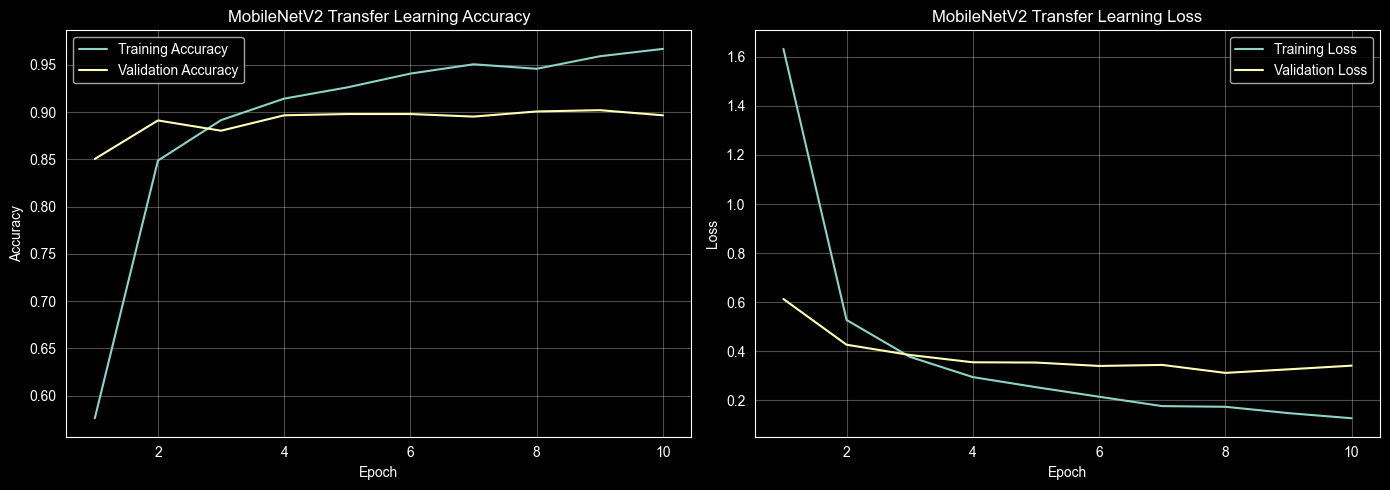

Saved MobileNetV2 training curves to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/figures/03_mobilenetv2_training_curves.png


In [19]:
#
# Plot Transfer Learning Training Curves
#

# Create a figure with two side-by-side plots.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot training and validation accuracy.
axes[0].plot(mobilenet_history_df["epoch"], mobilenet_history_df["accuracy"], label="Training Accuracy")
axes[0].plot(mobilenet_history_df["epoch"], mobilenet_history_df["val_accuracy"], label="Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("MobileNetV2 Transfer Learning Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot training and validation loss.
axes[1].plot(mobilenet_history_df["epoch"], mobilenet_history_df["loss"], label="Training Loss")
axes[1].plot(mobilenet_history_df["epoch"], mobilenet_history_df["val_loss"], label="Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("MobileNetV2 Transfer Learning Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Save the figure for later use in the report and presentation.
mobilenet_curves_path = FIGURE_DIR / "03_mobilenetv2_training_curves.png"
plt.savefig(mobilenet_curves_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved MobileNetV2 training curves to: {mobilenet_curves_path}")

## 16. Evaluate MobileNetV2 on the Test Set

After training, we evaluate the MobileNetV2 transfer learning model on the official test set.

The test set was not used during training or validation, so it provides a better estimate of how the model performs on unseen images.

In [20]:
#
# Evaluate MobileNetV2 on Test Set
#

# Evaluate the trained transfer learning model on the official test dataset.
mobilenet_test_loss, mobilenet_test_accuracy = transfer_model.evaluate(test_ds)

print(f"MobileNetV2 test loss: {mobilenet_test_loss:.4f}")
print(f"MobileNetV2 test accuracy: {mobilenet_test_accuracy:.4f}")

115/115 ━━━━━━━━━━━━━━━━━━━━ 15s 126ms/step - accuracy: 0.8907 - loss: 0.3412
MobileNetV2 test loss: 0.3412
MobileNetV2 test accuracy: 0.8907


## 17. Generate Test Predictions

To create a classification report and confusion matrix, we need predicted labels and true labels for every image in the test set.

In [21]:
#
# Generate Test Predictions
#

# Store true labels and predicted labels.
y_true = []
y_pred = []

# Loop through batches in the test dataset.
for image_batch, label_batch in test_ds:

    # Predict class probabilities for the current batch.
    batch_probabilities = transfer_model.predict(image_batch, verbose=0)

    # Convert probabilities to predicted class labels.
    batch_predictions = np.argmax(batch_probabilities, axis=1)

    # Store true and predicted labels.
    y_true.extend(label_batch.numpy())
    y_pred.extend(batch_predictions)

# Convert lists to NumPy arrays.
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of true labels:", len(y_true))
print("Number of predicted labels:", len(y_pred))
print("First 10 true labels:", y_true[:10])
print("First 10 predicted labels:", y_pred[:10])

Number of true labels: 3669
Number of predicted labels: 3669
First 10 true labels: [19 20 28 28  4 18 22 36 18 16]
First 10 predicted labels: [19 20 28 28  4 18 22 36 18 16]


2026-05-03 17:26:59.991145: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 18. Classification Report

The classification report summarizes precision, recall, and F1-score for each breed class.

This report allows us to identify which breeds the MobileNetV2 transfer learning model predicts well and which breeds remain more difficult.

In [22]:
#
# Create MobileNetV2 Classification Report
#

# Generate a classification report as a dictionary.
mobilenet_report = classification_report(
    y_true,
    y_pred,
    target_names=breed_names,
    output_dict=True,
    zero_division=0
)

# Convert the report to a DataFrame for display and saving.
mobilenet_report_df = pd.DataFrame(mobilenet_report).transpose()

# Save the classification report.
mobilenet_report_path = RESULTS_DIR / "03_mobilenetv2_classification_report.csv"

mobilenet_report_df.to_csv(mobilenet_report_path)

print(f"Saved MobileNetV2 classification report to: {mobilenet_report_path}")

mobilenet_report_df.head(10)

Saved MobileNetV2 classification report to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results/03_mobilenetv2_classification_report.csv


,precision,recall,f1-score,support
Abyssinian,0.848485,0.857143,0.852792,98.0
american_bulldog,0.714286,0.900000,0.796460,100.0
american_pit_bull_terrier,0.838710,0.520000,0.641975,100.0
basset_hound,0.978495,0.910000,0.943005,100.0
beagle,0.903846,0.940000,0.921569,100.0
Bengal,0.824176,0.750000,0.785340,100.0
Birman,0.773585,0.820000,0.796117,100.0
Bombay,0.875000,0.875000,0.875000,88.0
boxer,0.834862,0.919192,0.875000,99.0
British_Shorthair,0.730435,0.840000,0.781395,100.0


## 19. Confusion Matrix

The confusion matrix shows how often each true breed class was predicted as each possible breed class.

Compared with the baseline CNN confusion matrix, this matrix should show a much stronger diagonal pattern, meaning that the model more often predicts the correct breed.

In [23]:
#
# Create MobileNetV2 Confusion Matrix Table
#

# Compute the confusion matrix.
mobilenet_cm = confusion_matrix(y_true, y_pred)

# Convert the confusion matrix to a labeled DataFrame.
mobilenet_cm_df = pd.DataFrame(
    mobilenet_cm,
    index=breed_names,
    columns=breed_names
)

# Save the confusion matrix table.
mobilenet_cm_path = RESULTS_DIR / "03_mobilenetv2_confusion_matrix.csv"

mobilenet_cm_df.to_csv(mobilenet_cm_path)

print(f"Saved MobileNetV2 confusion matrix table to: {mobilenet_cm_path}")

mobilenet_cm_df.head()

Saved MobileNetV2 confusion matrix table to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results/03_mobilenetv2_confusion_matrix.csv


,Abyssinian,american_bulldog,american_pit_bull_terrier,basset_hound,beagle,Bengal,Birman,Bombay,boxer,British_Shorthair,...,Russian_Blue,saint_bernard,samoyed,scottish_terrier,shiba_inu,Siamese,Sphynx,staffordshire_bull_terrier,wheaten_terrier,yorkshire_terrier
Abyssinian,84,0,1,0,0,2,0,0,0,1,...,3,0,0,0,0,1,1,0,0,0
american_bulldog,0,90,1,0,0,0,0,0,4,0,...,0,2,1,0,0,0,0,2,0,0
american_pit_bull_terrier,0,15,52,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,27,0,0
basset_hound,0,0,0,91,7,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
beagle,0,2,0,2,94,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


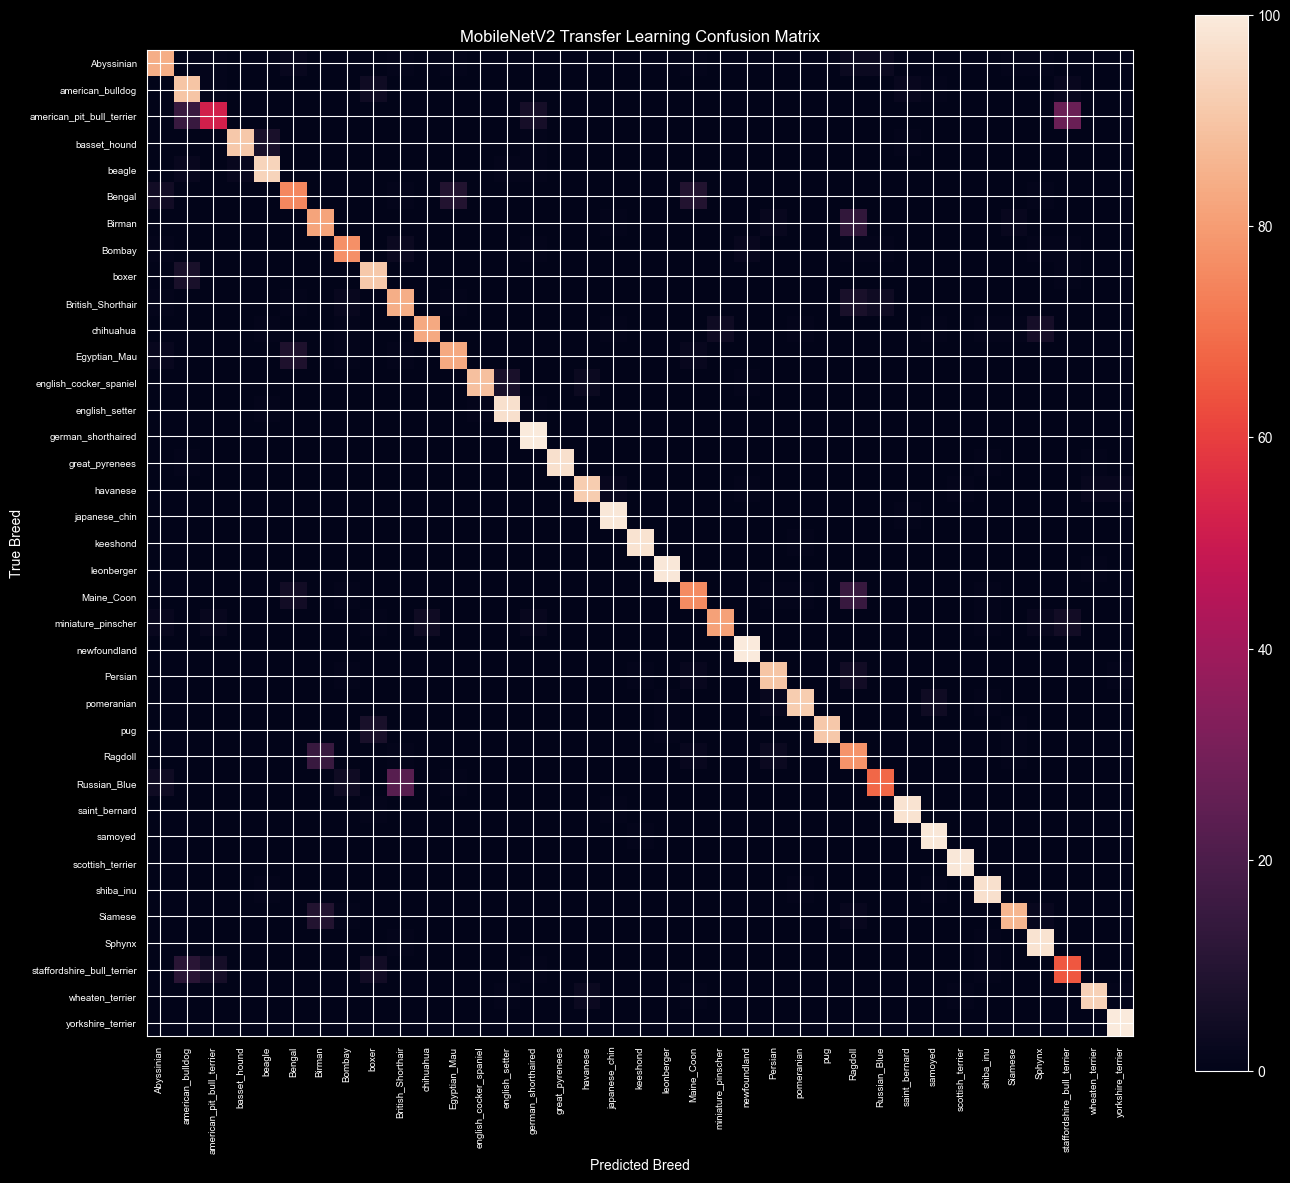

Saved MobileNetV2 confusion matrix plot to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/figures/03_mobilenetv2_confusion_matrix.png


In [24]:
#
# Plot MobileNetV2 Confusion Matrix
#

# Create a figure large enough to show all 37 class labels.
plt.figure(figsize=(14, 12))

plt.imshow(mobilenet_cm, interpolation="nearest")
plt.title("MobileNetV2 Transfer Learning Confusion Matrix")
plt.xlabel("Predicted Breed")
plt.ylabel("True Breed")

# Add class labels to both axes.
tick_marks = np.arange(len(breed_names))
plt.xticks(tick_marks, breed_names, rotation=90, fontsize=7)
plt.yticks(tick_marks, breed_names, fontsize=7)

# Add a colorbar to show count intensity.
plt.colorbar()

plt.tight_layout()

# Save the confusion matrix plot.
mobilenet_cm_fig_path = FIGURE_DIR / "03_mobilenetv2_confusion_matrix.png"
plt.savefig(mobilenet_cm_fig_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved MobileNetV2 confusion matrix plot to: {mobilenet_cm_fig_path}")

## 20. Save MobileNetV2 Test Metrics

This section saves a compact summary of the MobileNetV2 transfer learning model's test performance.

Later notebooks will use this table to compare the transfer learning model against the baseline CNN.

In [25]:
#
# Save MobileNetV2 Test Metrics
#

# Create a compact model summary table.
mobilenet_metrics_df = pd.DataFrame([
    {
        "model_name": "mobilenetv2_transfer_classifier",
        "model_type": "MobileNetV2 transfer learning, frozen base",
        "image_size": f"{IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}",
        "num_classes": NUM_CLASSES,
        "epochs_run": len(mobilenet_history_df),
        "best_validation_accuracy": mobilenet_history_df["val_accuracy"].max(),
        "best_validation_loss": mobilenet_history_df["val_loss"].min(),
        "test_accuracy": mobilenet_test_accuracy,
        "test_loss": mobilenet_test_loss
    }
])

# Save the MobileNetV2 metrics summary.
mobilenet_metrics_path = RESULTS_DIR / "03_mobilenetv2_metrics_summary.csv"

mobilenet_metrics_df.to_csv(mobilenet_metrics_path, index=False)

print(f"Saved MobileNetV2 metrics summary to: {mobilenet_metrics_path}")

mobilenet_metrics_df

Saved MobileNetV2 metrics summary to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results/03_mobilenetv2_metrics_summary.csv


,model_name,model_type,image_size,num_classes,epochs_run,best_validation_accuracy,best_validation_loss,test_accuracy,test_loss
0,mobilenetv2_transfer_classifier,"MobileNetV2 transfer learning, frozen base",224x224,37,10,0.902174,0.311386,0.890706,0.341241


## 21. Compare Baseline CNN and MobileNetV2

This section compares the custom CNN baseline from Notebook 02 with the MobileNetV2 transfer learning model from this notebook.

The purpose is to quantify the improvement from transfer learning.

In [26]:
#
# Compare Baseline CNN and MobileNetV2
#

# Load the baseline metrics saved in Notebook 02.
baseline_metrics_path = RESULTS_DIR / "02_baseline_metrics_summary.csv"

baseline_metrics_df = pd.read_csv(baseline_metrics_path)

# Combine baseline and MobileNetV2 metrics into one comparison table.
model_comparison_df = pd.concat(
    [baseline_metrics_df, mobilenet_metrics_df],
    ignore_index=True
)

# Add an accuracy improvement column relative to the baseline test accuracy.
baseline_test_accuracy_value = baseline_metrics_df.loc[0, "test_accuracy"]

model_comparison_df["test_accuracy_improvement_vs_baseline"] = (
        model_comparison_df["test_accuracy"] - baseline_test_accuracy_value
)

# Save the comparison table.
model_comparison_path = RESULTS_DIR / "03_model_comparison_summary.csv"

model_comparison_df.to_csv(model_comparison_path, index=False)

print(f"Saved model comparison summary to: {model_comparison_path}")

model_comparison_df

Saved model comparison summary to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results/03_model_comparison_summary.csv


,model_name,model_type,image_size,num_classes,epochs_run,best_validation_accuracy,best_validation_loss,test_accuracy,test_loss,test_accuracy_improvement_vs_baseline
0,baseline_custom_cnn,Custom CNN trained from scratch,224x224,37,20,0.126359,3.265255,0.111747,3.316179,0.000000
1,mobilenetv2_transfer_classifier,"MobileNetV2 transfer learning, frozen base",224x224,37,10,0.902174,0.311386,0.890706,0.341241,0.778959


## 22. Transfer Learning Interpretation

The MobileNetV2 transfer learning model substantially outperformed the custom CNN baseline.

The baseline custom CNN achieved approximately 11.17% test accuracy. In contrast, the frozen-base MobileNetV2 transfer learning model achieved approximately 89.07% test accuracy. This is an absolute improvement of approximately 77.90 percentage points.

This result supports one of the central lessons of the project: for a relatively small natural image dataset, transfer learning can provide much stronger performance than training a CNN from scratch. MobileNetV2 begins with pretrained visual features learned from ImageNet, so the model can adapt those features to pet breed classification with comparatively little training.

The frozen-base MobileNetV2 model also has practical deployment advantages. It is smaller and more efficient than many larger CNN architectures, which makes it a reasonable candidate for a future web or app-based pet breed recognition system.

## 23. Notebook Summary

This notebook built and evaluated the first transfer learning classification model for the project.

Completed steps:

1. Loaded the Oxford-IIIT Pet Dataset.
2. Created training, validation, and test datasets.
3. Applied MobileNetV2-specific preprocessing.
4. Loaded MobileNetV2 pretrained on ImageNet.
5. Trained a new classification head while keeping the MobileNetV2 base frozen.
6. Evaluated the model on the official test set.
7. Saved the model, training history, classification report, confusion matrix, and metrics summary.
8. Compared MobileNetV2 against the custom CNN baseline.

The next project step will be to use CNN embeddings for similarity-based image retrieval.